## TRANSF. DISCRETAS DE FOURIER 2D: RESUMO DIDÁTICO P/ PRÁTICA

Reveja os slides da aula teória de segunda-feira caso não se lembre do que eu revisei/ensinei nela.

1. **O QUE É CALCULADO:**
A FFT é obtida por um algoritmo mais rápido do que o algoritmo direto proposto no Burger (veja slides 15 a 20). Por isso o usamos aqui para computar a DFT. Veja:

   • FFT 2D decompõe a imagem em componentes senoidais  
   • **Magnitude** → força de cada componente de frequência  
   • **Fase** → deslocamento temporal de cada componente  
     *(não visualizada aqui; veja Gonzalez & Woods para detalhes)*

2. **RELAÇÃO ESPAÇO ↔ FREQUÊNCIA:**

   | **DOMÍNIO ESPACIAL** | **DOMÍNIO ESPECTRAL (FREQ)** |
   |:--------------------:|:-----------------------------:|
   | Objeto **PEQUENO**  | Frequências **ALTAS** (amplo) |
   | Objeto **GRANDE**   | Frequências **BAIXAS** (estreito) |
   | Borda **NÍTIDA**    | Altas frequências **fortes** |
   | Transição **SUAVE** | Altas frequências **fracas** |
   | Padrão **periódico**| Picos em **frequências fixas** |
   
3. **ESCALAS DE VISUALIZAÇÃO:**
Ao final da aula teórica (slide 28) mostramos diversas imagens e suas transformadas. Foi explicado que como a componente DC é muito grande em relação a outras componentes da transformada. Ela pode ficar um ponto brilhante no escuro. Para visualizar o restante usamos o conceito de transformações pontuais que já estudamos:


   **LINEAR:**  
   $s = \frac{r}{\max(r)}$

   **LOGARÍTMICA:**  
   $s = \frac{\log(1 + r)}{\max(\log(1 + r))}$

   • Amplifica valores pequenos  
   • Mostra detalhes em baixas frequências  
   • Padrão em PDI clássica *(Gonzalez & Woods)*  

   **PARECEM IGUAIS?** verificar: dinâmica reduzida + normalização dupla!

4. **QUANDO VER DIFERENÇAS:**

   • Dinâmica espectral **> 100×** → diferenças visíveis  
   • Múltiplos objetos de tamanhos diferentes  
   • Texturas complexas ou imagens naturais  
   ✗ Formas simples (*quadrados, círculos*) → dinâmica baixa

5. **PROPRIEDADES IMPORTANTES:**

   • **Simetria:** imagens reais → espectro simétrico  
   • **Linearidade:** F[a·f + b·g] = a·F[f] + b·F[g]

   • **Separabilidade:** FFT 2D = FFT 1D (linhas) + FFT 1D (colunas)  
   • **Translação:** F[f(x-x₀, y-y₀)] = F(u,v)·e^(-j·2π(ux₀+vy₀))

   • **Magnitude não muda**, **fase muda** *(ver experimento 3)*

6. **APLICAÇÕES:**

   **Filtros** no domínio da frequência  
   **Compressão de imagens** — JPEG usa DCT (variante de Fourier)  
   **Detecção de periodicidades**  
   **Análise de texturas**  
   **Reconstrução:** IFFT (inversa) para voltar ao domínio espacial

## 1. Importações e Configuração

In [ ]:
import numpy as np
import numpy.fft as fp
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Configurações visuais
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['image.cmap'] = 'gray'

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 2. Módulo de Escalas Espectrais - CENTRALIZADO

In [ ]:
class EscalasEspectro:
    """
    Centralizador de funções de escala espectral.
    Implementa as escalas padrão conforme Gonzalez & Woods (2008).
    """

    @staticmethod
    def linear_puro(magnitude):
        """Escala linear pura: r_normalizado = r / max(r)

        Melhor para: Componentes com alta energia concentrada
        Problema: Valores baixos são muito comprimidos
        """
        m = np.asarray(magnitude, dtype=np.float32)
        m_max = float(np.max(m)) if m.size > 0 else 1.0
        if not np.isfinite(m_max) or m_max <= 0:
            return np.zeros_like(m, dtype=np.float32)
        return (m / m_max).astype(np.float32)

    @staticmethod
    def logaritmica_gonzalez(magnitude, c=1.0):
        """Escala logarítmica padrão (Gonzalez & Woods): s = c * log(1 + r)

        Melhor para: Dinâmica espectral muito grande (100:1 ou mais)
        Teoricamente justificada em PDI clássico

        Parâmetro c: controla o contraste (tipicamente 1.0 a 10.0)
        """
        m = np.asarray(magnitude, dtype=np.float32)
        return c * np.log1p(m).astype(np.float32)

    @staticmethod
    def logaritmica_potencia(magnitude, c=1.0):
        """Escala logarítmica de potência: s = c * log(1 + r²)

        Variante que amplifica ainda mais as baixas frequências
        Útil para espectros muito esparssos
        """
        m = np.asarray(magnitude, dtype=np.float32)
        return c * np.log1p(m ** 2).astype(np.float32)

    @staticmethod
    def normalizar_01(matriz):
        """Normaliza matriz para intervalo [0, 1]

        Use APÓS aplicar escala (linear ou log) !
        NÃO use entre duas escalas (evita dupla normalização) !
        """
        m = np.asarray(matriz, dtype=np.float32)
        m_min = float(np.min(m))
        m_max = float(np.max(m))

        if m_max - m_min <= 0:
            return np.ones_like(m, dtype=np.float32) * 0.5

        return ((m - m_min) / (m_max - m_min)).astype(np.float32)


print("Classe EscalasEspectro definida e centralizada!")

Classe EscalasEspectro definida e centralizada!


## 3. Funções de Visualização

In [ ]:
def visualizar_imagem_espacial(imagem, titulo="Imagem Original"):
    """Visualiza imagem no domínio espacial com cores adequadas."""
    plt.figure(figsize=(8, 8))

    if np.issubdtype(imagem.dtype, np.integer):
        vmax = 255 if imagem.dtype == np.uint8 else float(np.max(imagem))
        plt.imshow(imagem, cmap='gray', vmin=0, vmax=vmax)
    else:
        plt.imshow(imagem, cmap='gray')

    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.xlabel('x (pixels)')
    plt.ylabel('y (pixels)')
    plt.colorbar(label='Intensidade')
    plt.grid(False)
    plt.tight_layout()
    plt.show()


def visualizar_espectro_unico(magnitude, escala='log', centrado=False,
                               titulo=None, cmap='hot'):
    """Visualiza um único espectro com escala especificada.

    Parâmetros:
    -----------
    magnitude : ndarray
        Magnitude da transformada (bruta ou centrada)
    escala : str
        'linear', 'log' (Gonzalez) ou 'log_potencia'
    centrado : bool
        Se False, assume que já está centrada
    titulo : str
        Título customizado
    """
    if centrado and np.mean(magnitude) > 0:
        mag_proc = fp.fftshift(magnitude)
    else:
        mag_proc = magnitude

    # Aplicar escala
    if escala.lower() == 'linear':
        img_proc = EscalasEspectro.linear_puro(mag_proc)
    elif escala.lower() == 'log_potencia':
        img_proc = EscalasEspectro.normalizar_01(
            EscalasEspectro.logaritmica_potencia(mag_proc)
        )
    else:  # 'log' padrão
        img_proc = EscalasEspectro.normalizar_01(
            EscalasEspectro.logaritmica_gonzalez(mag_proc)
        )

    plt.figure(figsize=(10, 8))
    im = plt.imshow(img_proc, cmap=cmap)
    plt.title(titulo or f"Espectro ({escala.upper()})", fontsize=12, fontweight='bold')
    plt.colorbar(im, label='Magnitude')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return img_proc


def comparar_escalas(magnitude, centrado=False, mostra_perfis=True):
    """Visualiza Linear, Log-Gonzalez e Log-Potência lado a lado.

    ESTA É A FUNÇÃO PARA VER AS DIFERENÇAS REAIS!
    """
    if centrado and np.mean(magnitude) > 0:
        mag = fp.fftshift(magnitude)
    else:
        mag = magnitude

    # Aplicar escalas
    linear = EscalasEspectro.linear_puro(mag)
    log_gz = EscalasEspectro.normalizar_01(
        EscalasEspectro.logaritmica_gonzalez(mag)
    )
    log_pot = EscalasEspectro.normalizar_01(
        EscalasEspectro.logaritmica_potencia(mag)
    )

    fig = plt.figure(figsize=(18, 6))

    # Visualizações principais
    ax1 = plt.subplot(1, 3, 1)
    im1 = ax1.imshow(linear, cmap='hot')
    ax1.set_title('Escala LINEAR\ns = r / max(r)', fontweight='bold')
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1)

    ax2 = plt.subplot(1, 3, 2)
    im2 = ax2.imshow(log_gz, cmap='hot')
    ax2.set_title('Escala LOG (Gonzalez)\ns = log(1 + r)', fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2)

    ax3 = plt.subplot(1, 3, 3)
    im3 = ax3.imshow(log_pot, cmap='hot')
    ax3.set_title('Escala LOG (Potência)\ns = log(1 + r²)', fontweight='bold')
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3)

    plt.tight_layout()
    plt.show()

    # Perfis 1D para análise numérica
    if mostra_perfis:
        h, w = mag.shape
        perfil_h = mag[h//2, :]

        fig, ax = plt.subplots(figsize=(14, 5))

        # Normalizar para comparação justa
        perf_lin = EscalasEspectro.linear_puro(perfil_h)
        perf_log_gz = EscalasEspectro.normalizar_01(
            EscalasEspectro.logaritmica_gonzalez(perfil_h)
        )
        perf_log_pot = EscalasEspectro.normalizar_01(
            EscalasEspectro.logaritmica_potencia(perfil_h)
        )

        x = np.arange(len(perfil_h))
        ax.plot(x, perf_lin, 'r-', linewidth=2, label='Linear')
        ax.plot(x, perf_log_gz, 'g-', linewidth=2, label='Log (Gonzalez)')
        ax.plot(x, perf_log_pot, 'b-', linewidth=2, label='Log (Potência)')

        ax.set_xlabel('Frequência u', fontsize=11)
        ax.set_ylabel('Magnitude (normalizada)', fontsize=11)
        ax.set_title('Perfil Horizontal - COMPARAÇÃO DE ESCALAS', fontweight='bold')
        ax.legend(loc='upper right', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('linear')

        plt.tight_layout()
        plt.show()

        # Estatísticas
        print("\n" + "="*70)
        print("ANÁLISE NUMÉRICA - Por que as escalas parecem iguais")
        print("="*70)
        print(f"Dinâmica do perfil: {np.max(perfil_h) / (np.min(perfil_h) + 1e-10):.2f}x")
        print(f"Diferença máxima (Linear vs Log-Gonzalez): {np.max(np.abs(perf_lin - perf_log_gz)):.4f}")
        print(f"Diferença máxima (Linear vs Log-Potência): {np.max(np.abs(perf_lin - perf_log_pot)):.4f}")
        print(f"Correlação (Linear vs Log-Gonzalez): {np.corrcoef(perf_lin, perf_log_gz)[0,1]:.4f}")
        print("\n Dinâmica < 10x? Escalas parecem similares após normalização.")
        print(" Dinâmica > 100x? Diferenças ficam visíveis!")
        print("="*70 + "\n")

    return linear, log_gz, log_pot


print("Funções de visualização definidas!")

Funções de visualização definidas!


## 4. Criar Imagem de Teste

  Imagem criada: 1024x1024 pixels
  Quadrado: 40x40 pixels
  Posição: centro (512, 512)


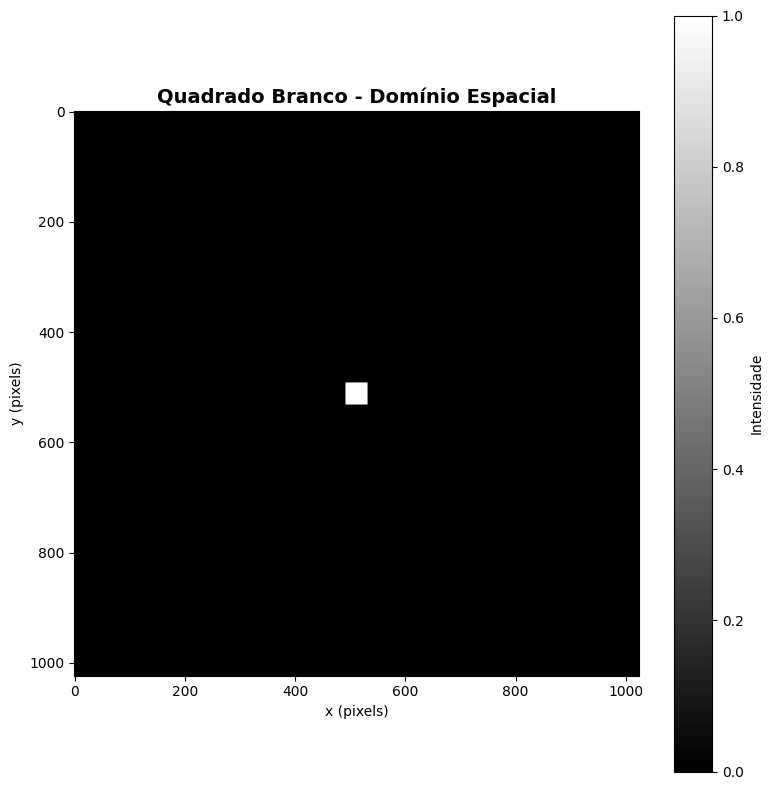

In [ ]:
# Parâmetros
N = 2**10  # 1024 pixels (potência de 2 para eficiência FFT)
largura_quadrado = 20   # pixels na direção x
altura_quadrado = 20    # pixels na direção y

# Criar imagem (fundo preto)
imagem = np.zeros((N, N), dtype=np.float32)

# Adicionar quadrado branco no centro
centro_y, centro_x = N // 2, N // 2
imagem[centro_y - altura_quadrado : centro_y + altura_quadrado,
        centro_x - largura_quadrado : centro_x + largura_quadrado] = 1.0

print(f"  Imagem criada: {N}x{N} pixels")
print(f"  Quadrado: {2*largura_quadrado}x{2*altura_quadrado} pixels")
print(f"  Posição: centro ({centro_x}, {centro_y})")

# Visualizar
visualizar_imagem_espacial(imagem, "Quadrado Branco - Domínio Espacial")

## 5. Calcular FFT 2D e Magnitude

In [ ]:
# 1. Calculando a magnitude NÃO-CENTRADA ou BRUTA
print("Calculando FFT 2D...")
transformada = fp.fft2(imagem)
magnitude = np.abs(transformada)

print(f"  Magnitude calculada!")
print(f"  Valor máximo: {magnitude.max():.2e}")
print(f"  Valor mínimo: {magnitude.min():.2e}")
print(f"  Dinâmica (max/min): {magnitude.max() / (magnitude.min() + 1e-10):.2e}x")

Calculando FFT 2D...
  Magnitude calculada!
  Valor máximo: 1.60e+03
  Valor mínimo: 0.00e+00
  Dinâmica (max/min): 1.60e+13x


## 6. COMPARAÇÃO PRINCIPAL: Linear vs Logarítmica


VISUALIZAÇÃO: POR QUE OS ESPECTROS PARECEM IGUAIS?


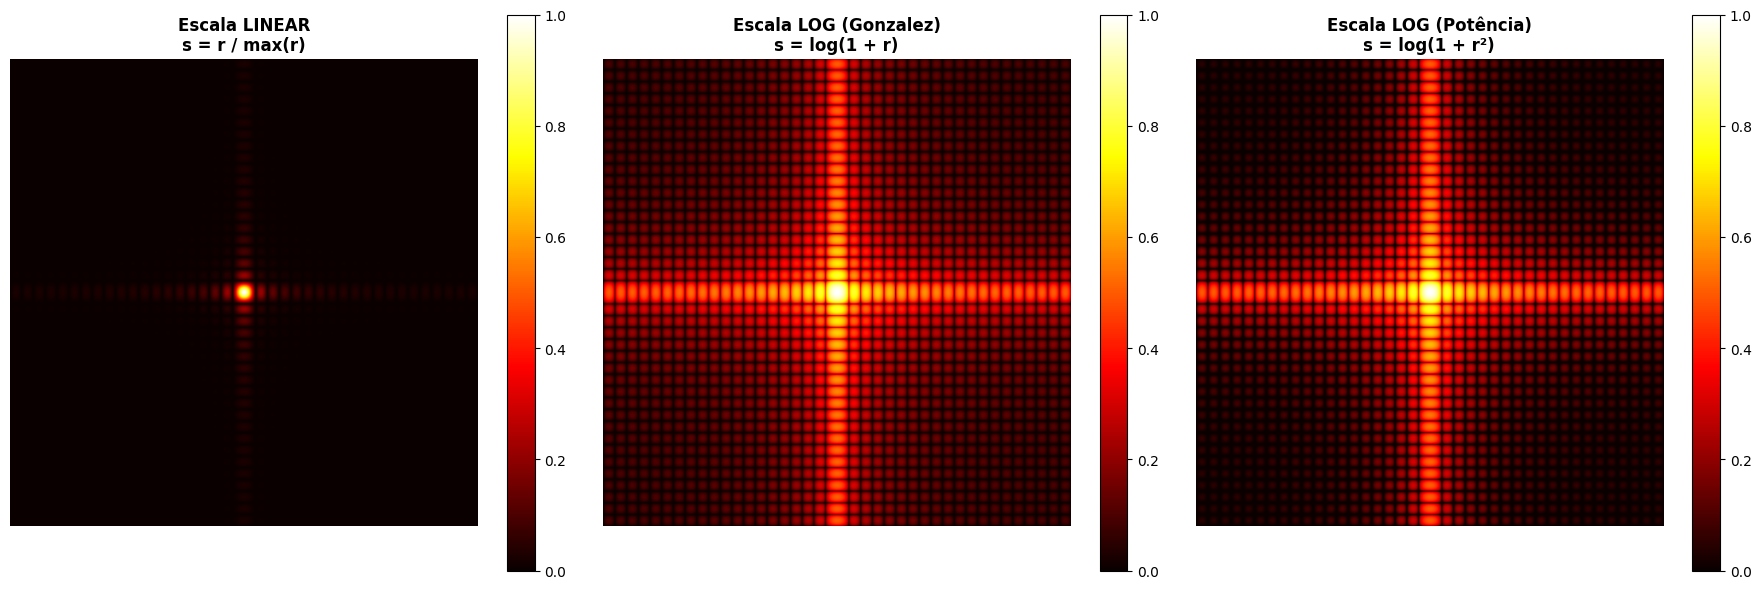

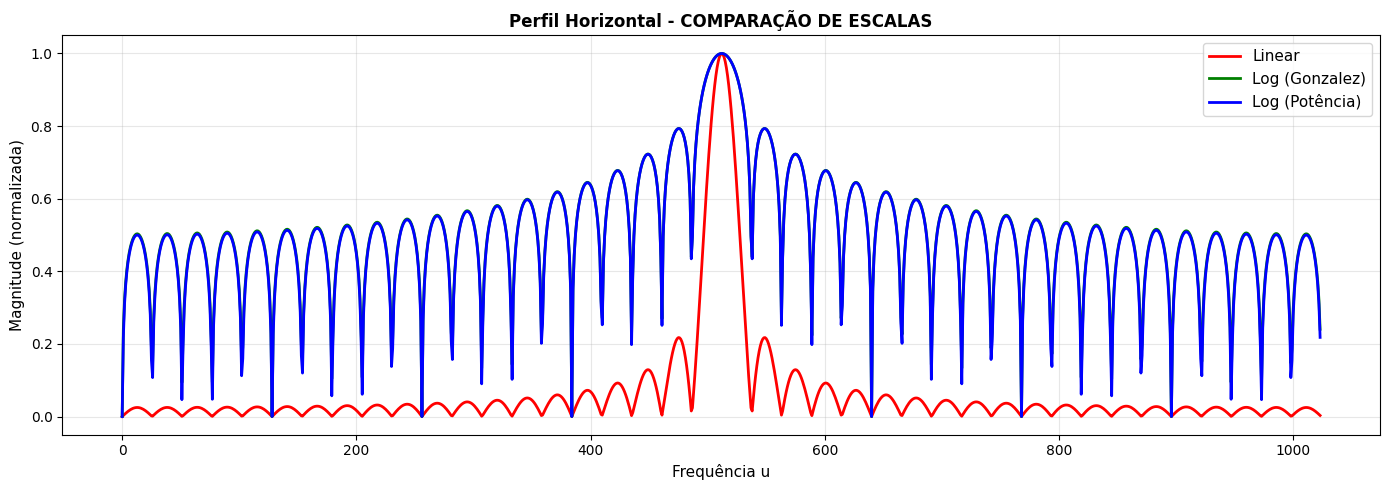


ANÁLISE NUMÉRICA - Por que as escalas parecem iguais
Dinâmica do perfil: 15999999934464.00x
Diferença máxima (Linear vs Log-Gonzalez): 0.5941
Diferença máxima (Linear vs Log-Potência): 0.5935
Correlação (Linear vs Log-Gonzalez): 0.6995

 Dinâmica < 10x? Escalas parecem similares após normalização.
 Dinâmica > 100x? Diferenças ficam visíveis!



(array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 9.3653216e-06, 1.8590043e-05, ..., 2.7535669e-05,
         1.8590041e-05, 9.3653216e-06],
        [0.0000000e+00, 1.8590043e-05, 3.6900990e-05, ..., 5.4657943e-05,
         3.6900994e-05, 1.8590041e-05],
        ...,
        [0.0000000e+00, 2.7535669e-05, 5.4657943e-05, ..., 8.0959631e-05,
         5.4657943e-05, 2.7535667e-05],
        [0.0000000e+00, 1.8590041e-05, 3.6900994e-05, ..., 5.4657947e-05,
         3.6900990e-05, 1.8590043e-05],
        [0.0000000e+00, 9.3653216e-06, 1.8590041e-05, ..., 2.7535667e-05,
         1.8590043e-05, 9.3653216e-06]], dtype=float32),
 array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.0020158 , 0.00397245, ..., 0.00584331, 0.00397245,
         0.0020158 ],
        [0.        , 0.00397245, 0.00777465, ..., 0.01136265, 0.00777465,
         0.00397245]

In [ ]:
print("\n" + "="*70)
print("VISUALIZAÇÃO: POR QUE OS ESPECTROS PARECEM IGUAIS?")
print("="*70)

# 2. Passando a magnitude BRUTA para a função e pedindo para ELA centralizar
comparar_escalas(magnitude, centrado=True, mostra_perfis=True)

## 7. Análise com Imagem de Alta Dinâmica

Para ver diferenças reais entre escalas, precisamos de alta dinâmica espectral:

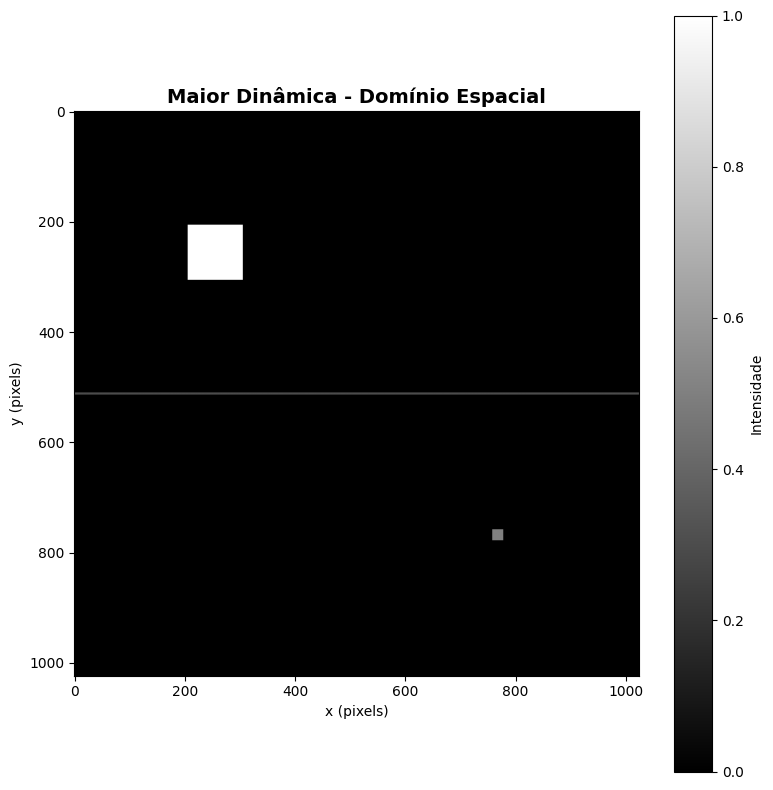

Imagem com maior dinâmica espectral criada!
Dinâmica: 1.14e+14x


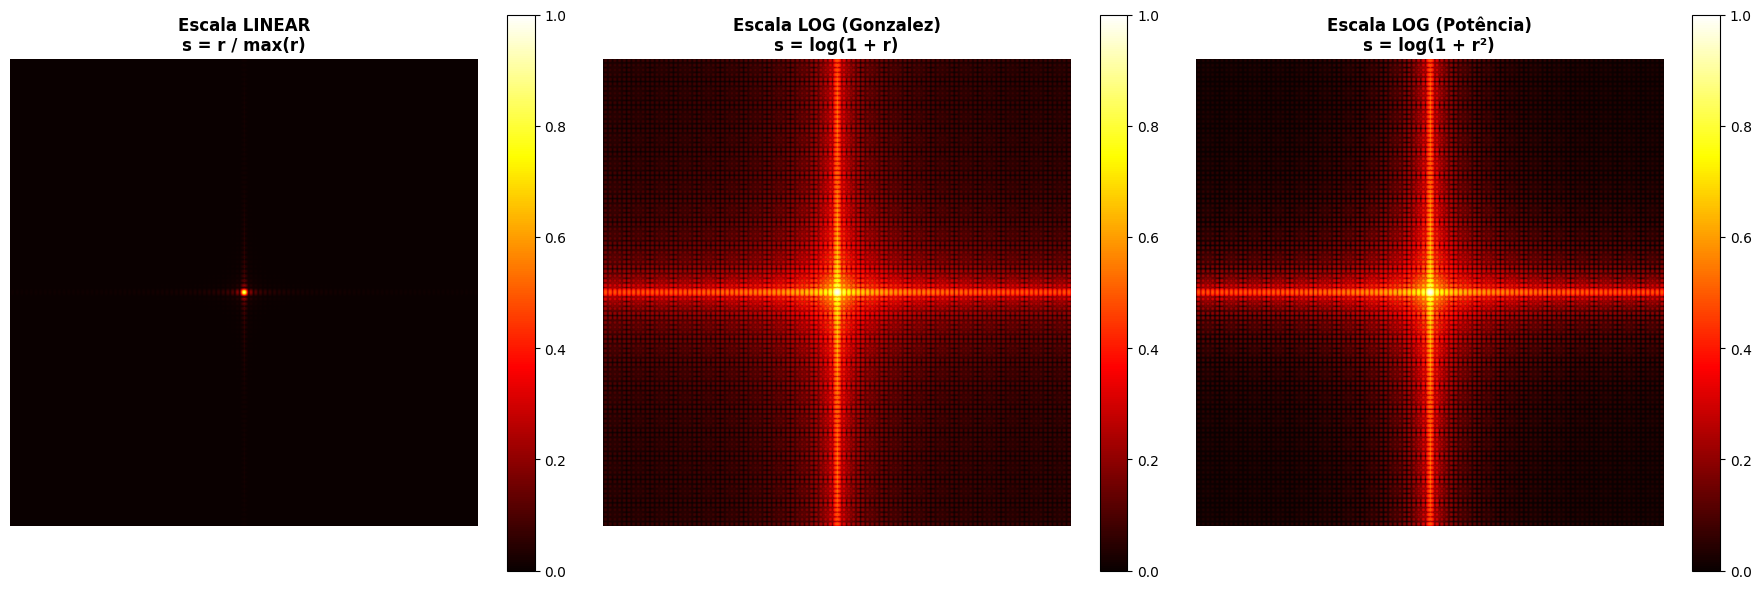

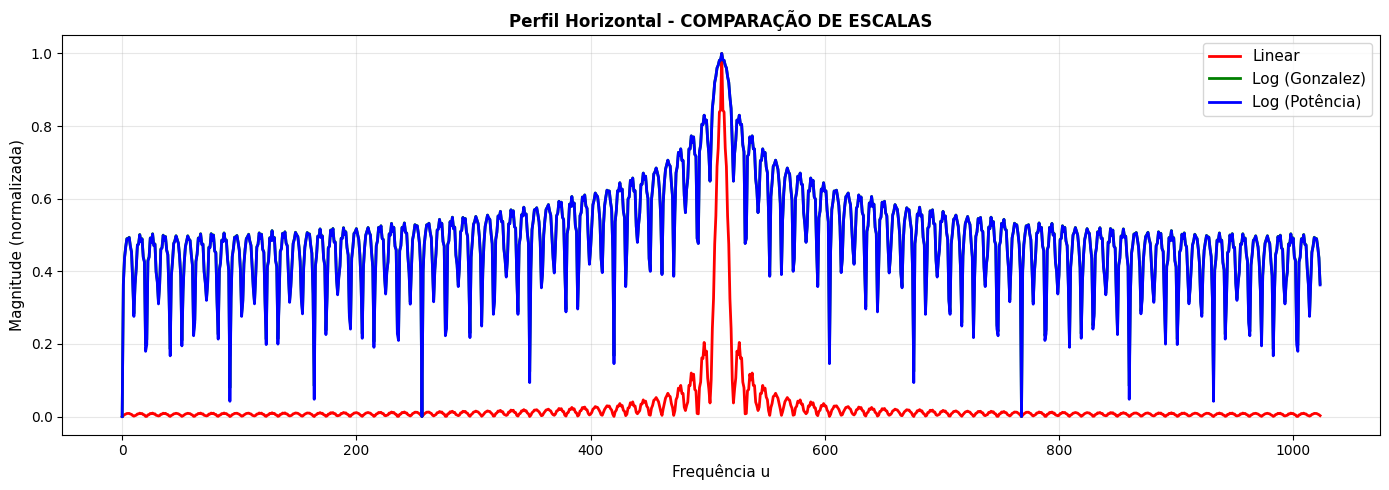


ANÁLISE NUMÉRICA - Por que as escalas parecem iguais
Dinâmica do perfil: 114287997616128.00x
Diferença máxima (Linear vs Log-Gonzalez): 0.6539
Diferença máxima (Linear vs Log-Potência): 0.6538
Correlação (Linear vs Log-Gonzalez): 0.5895

 Dinâmica < 10x? Escalas parecem similares após normalização.
 Dinâmica > 100x? Diferenças ficam visíveis!



(array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 8.14508803e-06, 1.48876816e-05, ...,
         2.15220443e-05, 1.48876816e-05, 8.14508803e-06],
        [0.00000000e+00, 1.48876825e-05, 2.96671551e-05, ...,
         3.91181711e-05, 2.96671587e-05, 1.48876816e-05],
        ...,
        [0.00000000e+00, 2.15220443e-05, 3.91181675e-05, ...,
         5.68881478e-05, 3.91181711e-05, 2.15220425e-05],
        [0.00000000e+00, 1.48876816e-05, 2.96671587e-05, ...,
         3.91181711e-05, 2.96671551e-05, 1.48876825e-05],
        [0.00000000e+00, 8.14508803e-06, 1.48876816e-05, ...,
         2.15220425e-05, 1.48876816e-05, 8.14508803e-06]], dtype=float32),
 array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.00952563, 0.01681623, ..., 0.0235355 , 0.01681623,
         0.00952563],
        [0.        , 0.01681623, 0.03124663, ..., 0.039548

In [ ]:
# Criar imagem com múltiplos padrões (maior dinâmica espectral)
imagem_complexa = np.zeros((N, N), dtype=np.float32)

# Quadrado 1 (grande e branco)
cx1, cy1 = N//4, N//4
imagem_complexa[cy1-50:cy1+50, cx1-50:cx1+50] = 1.0

# Quadrado 2 (pequeno e cinza)
cx2, cy2 = 3*N//4, 3*N//4
imagem_complexa[cy2-10:cy2+10, cx2-10:cx2+10] = 0.5

# Linha horizontal cinza
imagem_complexa[N//2-2:N//2+2, :] = 0.3

# Visualizar
visualizar_imagem_espacial(imagem_complexa, "Maior Dinâmica - Domínio Espacial")

# Calcular FFT
transf_complexa = fp.fft2(imagem_complexa)
mag_complexa = np.abs(transf_complexa)

print("Imagem com maior dinâmica espectral criada!")

print(f"Dinâmica: {mag_complexa.max() / (mag_complexa.min() + 1e-10):.2e}x")

comparar_escalas(mag_complexa, centrado=True, mostra_perfis=True)

## 8. Experimentos Interativos com Diferentes Formas

 Função criar_e_analisar definida!

Executando experimentos...

[1] Quadrado Pequeno (tamanho=10)


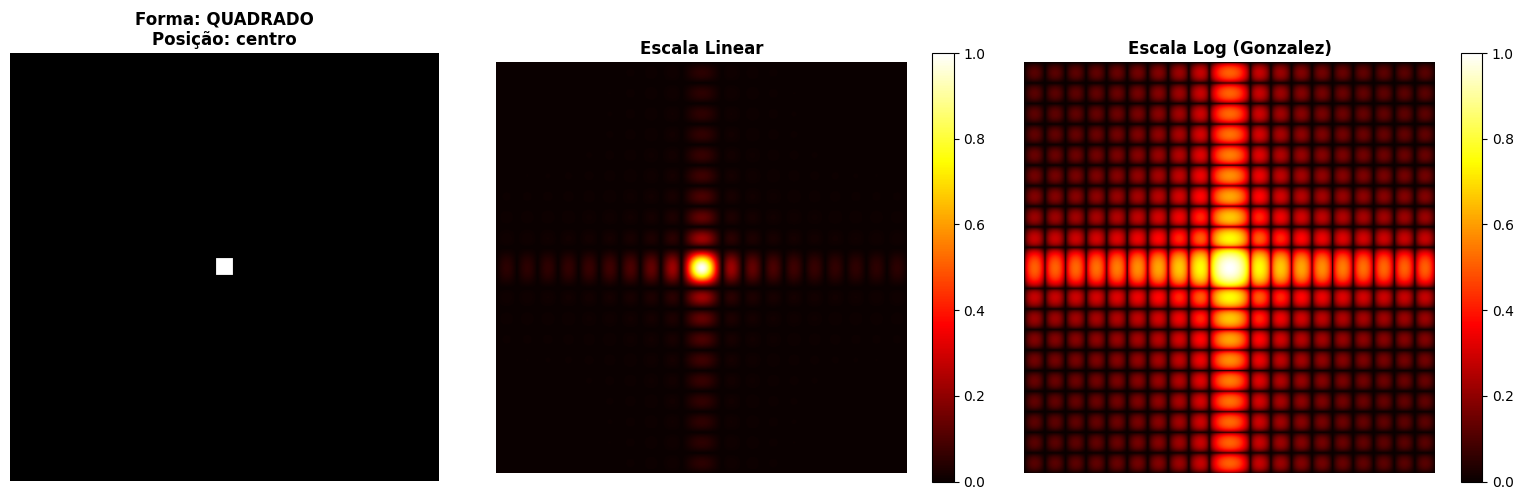

[2] Quadrado Grande (tamanho=50)


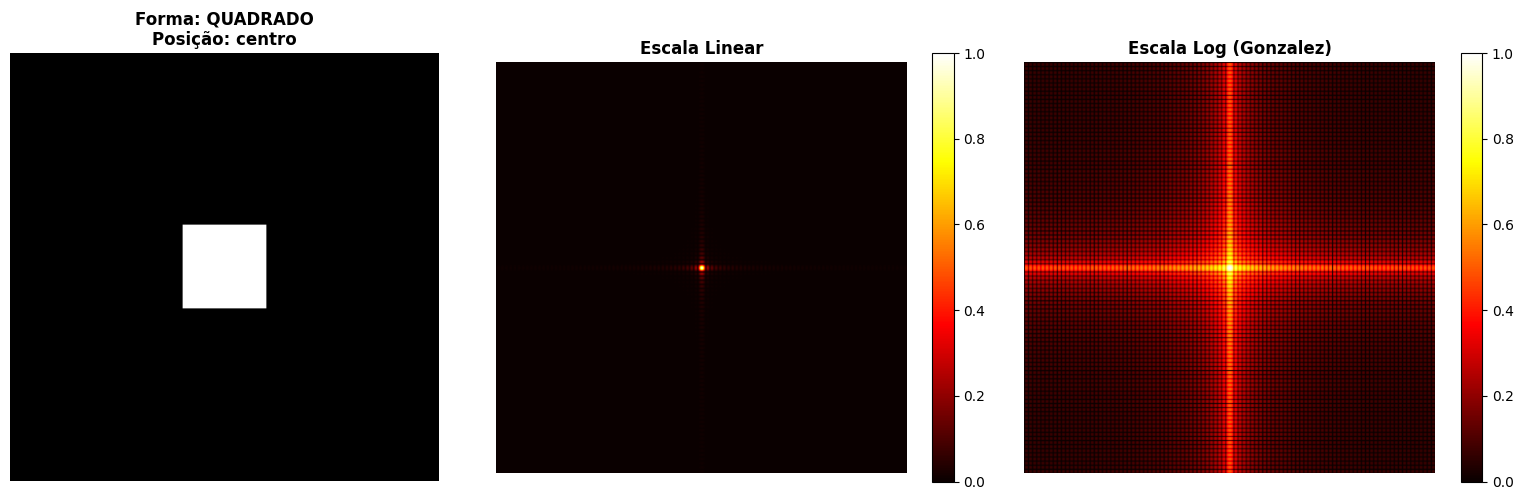

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.33156753, 0.5421998 , ..., 0.55505455, 0.5421998 ,
         0.33156756],
        [0.        , 0.5421998 , 0.8866387 , ..., 0.90765977, 0.88663876,
         0.5421998 ],
        ...,
        [0.        , 0.55505455, 0.90765977, ..., 0.9291791 , 0.90765977,
         0.55505455],
        [0.        , 0.5421998 , 0.88663876, ..., 0.90765977, 0.8866387 ,
         0.5421998 ],
        [0.        , 0.33156756, 0.5421998 , ..., 0.5550546 , 0.5421998 ,
         0.33156753]], dtype=float32))

In [ ]:
def criar_e_analisar(N=512, forma='quadrado', tamanho=20, posicao='centro'):
    """Cria forma e analisa seu espectro."""
    img = np.zeros((N, N), dtype=np.float32)

    # Definir posição
    if posicao == 'centro':
        cy, cx = N // 2, N // 2
    elif posicao == 'canto':
        cy, cx = N // 4, N // 4
    else:
        cy, cx = np.random.randint(tamanho, N - tamanho, 2)

    # Desenhar forma
    if forma == 'quadrado':
        img[cy - tamanho: cy + tamanho, cx - tamanho: cx + tamanho] = 1.0

    elif forma == 'circulo':
        y, x = np.ogrid[-cy:N - cy, -cx:N - cx]
        mascara = x*x + y*y <= tamanho*tamanho
        img[mascara] = 1.0

    elif forma == 'linha_h':
        img[cy - 2: cy + 2, :] = 1.0

    elif forma == 'linha_v':
        img[:, cx - 2: cx + 2] = 1.0

    elif forma == 'cruz':
        img[cy - 2: cy + 2, :] = 1.0
        img[:, cx - 2: cx + 2] = 1.0

    # Transformada
    F = fp.fft2(img)
    mag = np.abs(F)
    mag_centrada = fp.fftshift(mag)

    # Visualização 3 painéis
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Original
    axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Forma: {forma.upper()}\nPosição: {posicao}', fontweight='bold')
    axes[0].axis('off')

    # Linear
    linear = EscalasEspectro.linear_puro(mag_centrada)
    im1 = axes[1].imshow(linear, cmap='hot')
    axes[1].set_title('Escala Linear', fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])

    # Log
    log_gz = EscalasEspectro.normalizar_01(
        EscalasEspectro.logaritmica_gonzalez(mag_centrada)
    )
    im2 = axes[2].imshow(log_gz, cmap='hot')
    axes[2].set_title('Escala Log (Gonzalez)', fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

    return img, mag_centrada


print(" Função criar_e_analisar definida!")
print("\nExecutando experimentos...\n")

# Experimento 1: Tamanhos diferentes
print("[1] Quadrado Pequeno (tamanho=10)")
criar_e_analisar(N=512, forma='quadrado', tamanho=10)

print("[2] Quadrado Grande (tamanho=50)")
criar_e_analisar(N=512, forma='quadrado', tamanho=50)

[3] Forma: CIRCULO


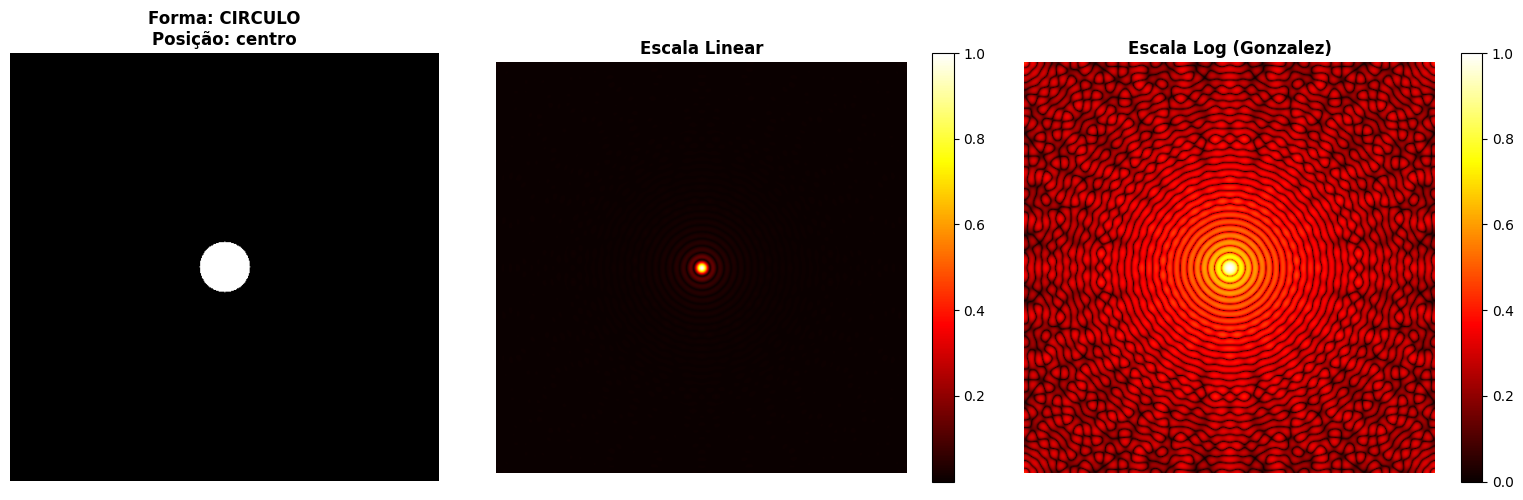

[4] Forma: LINHA_H


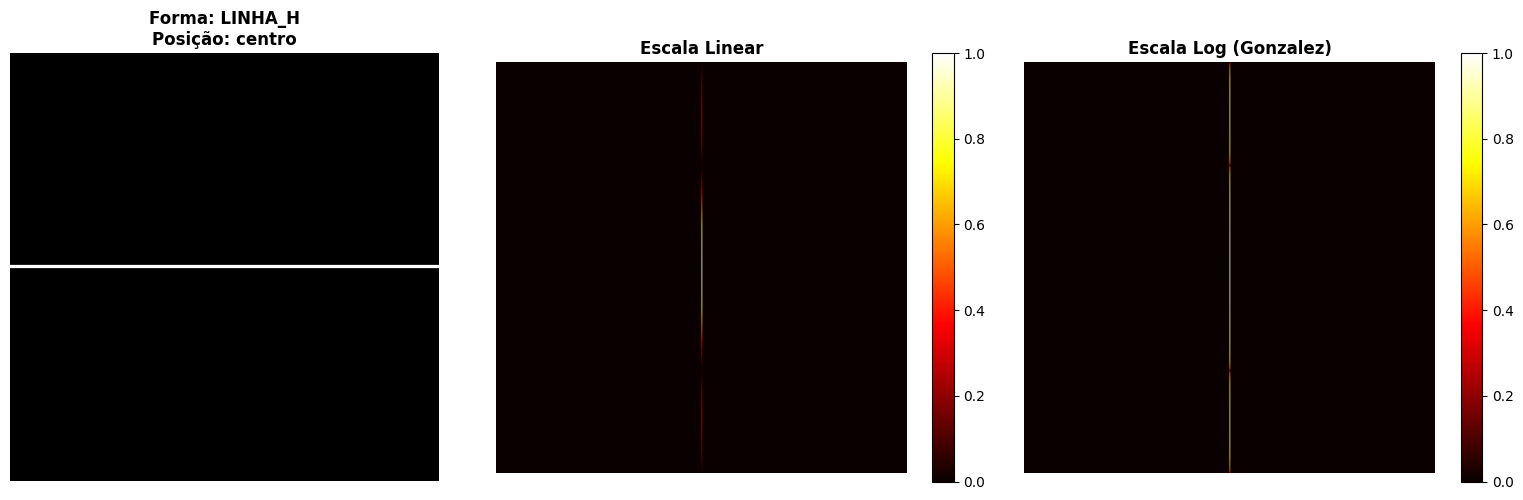

[5] Forma: LINHA_V


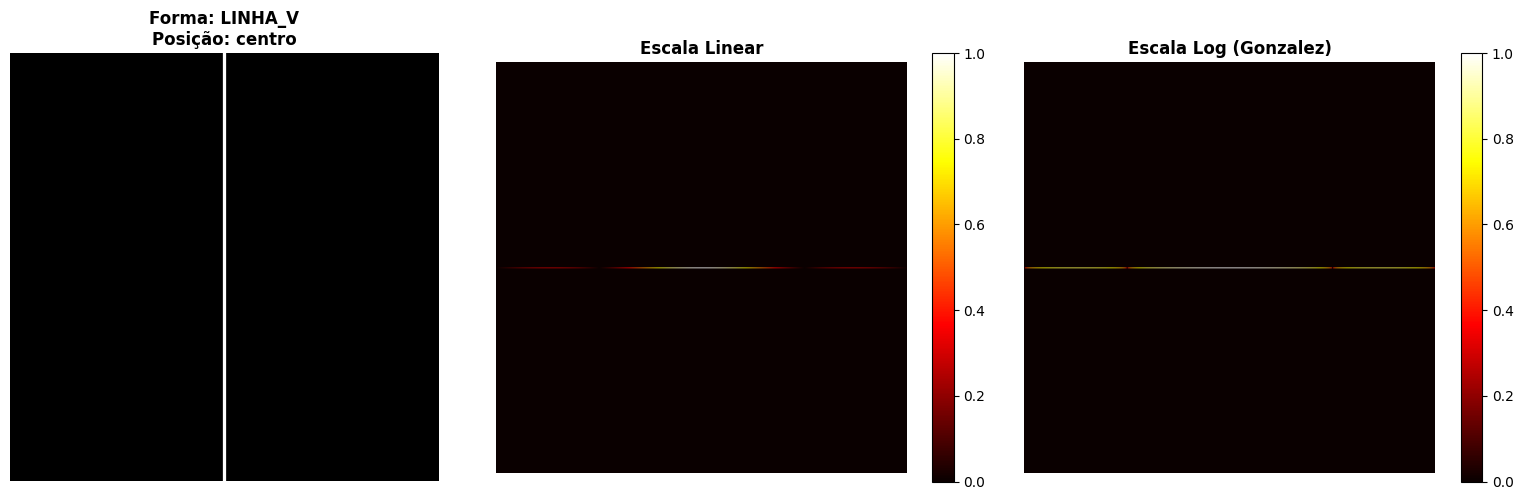

[6] Forma: CRUZ


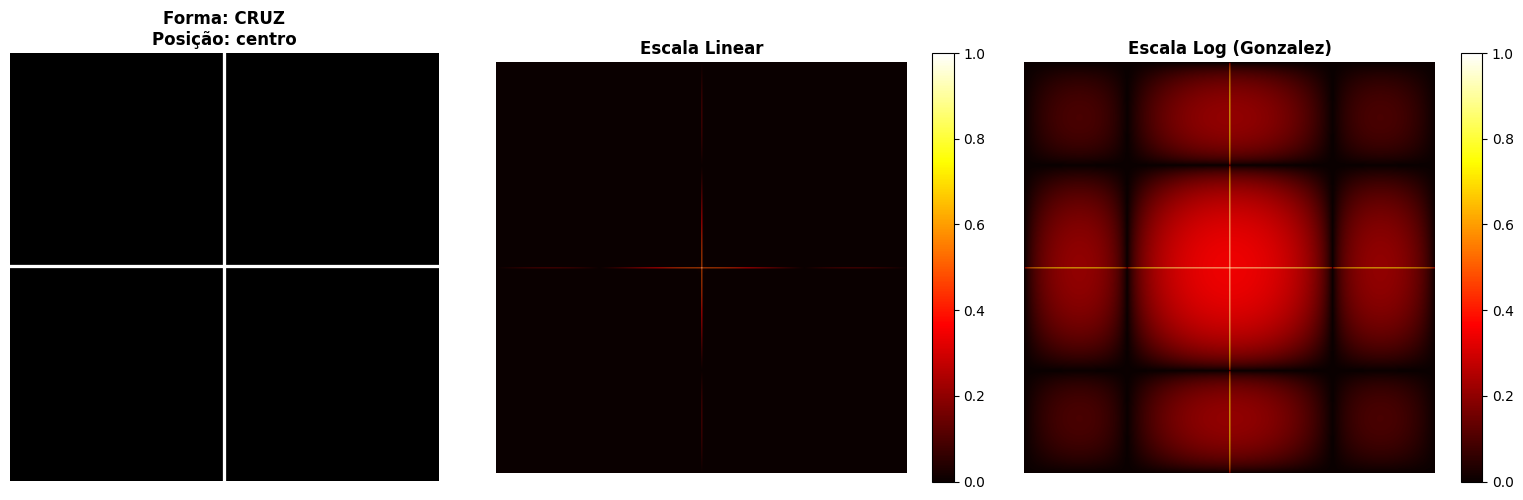

In [ ]:
# Experimento 2: Diferentes formas
formas = ['circulo', 'linha_h', 'linha_v', 'cruz']

for i, forma in enumerate(formas, 3):
    print(f"[{i}] Forma: {forma.upper()}")
    criar_e_analisar(N=512, forma=forma, tamanho=30)

[7] Quadrado no CENTRO


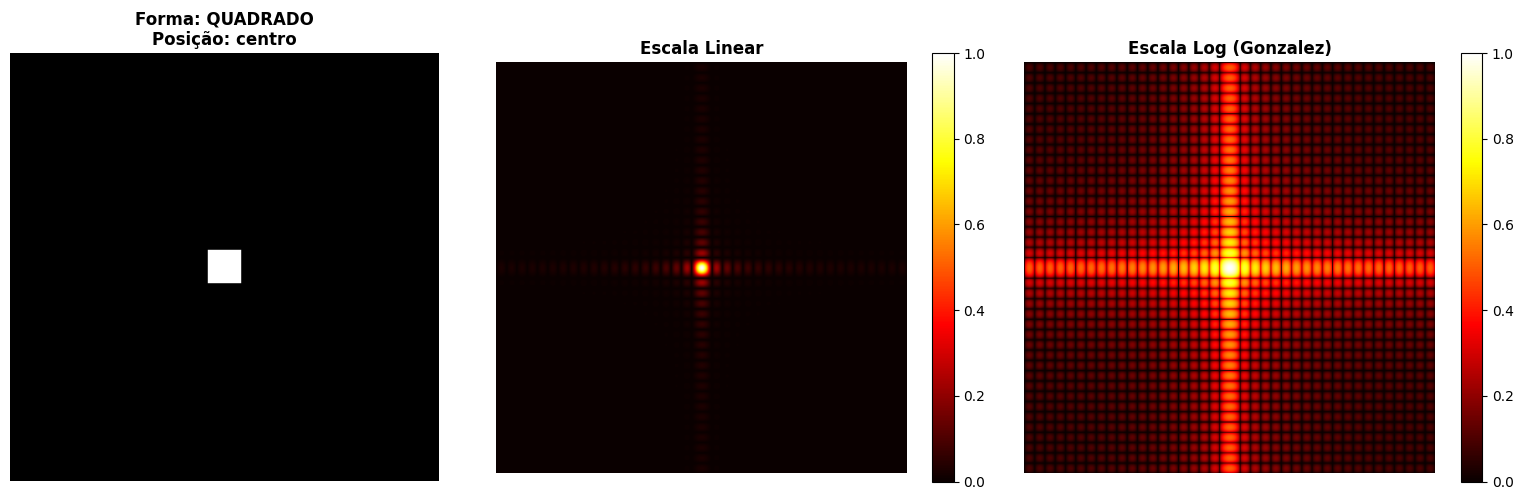

[8] Quadrado no CANTO


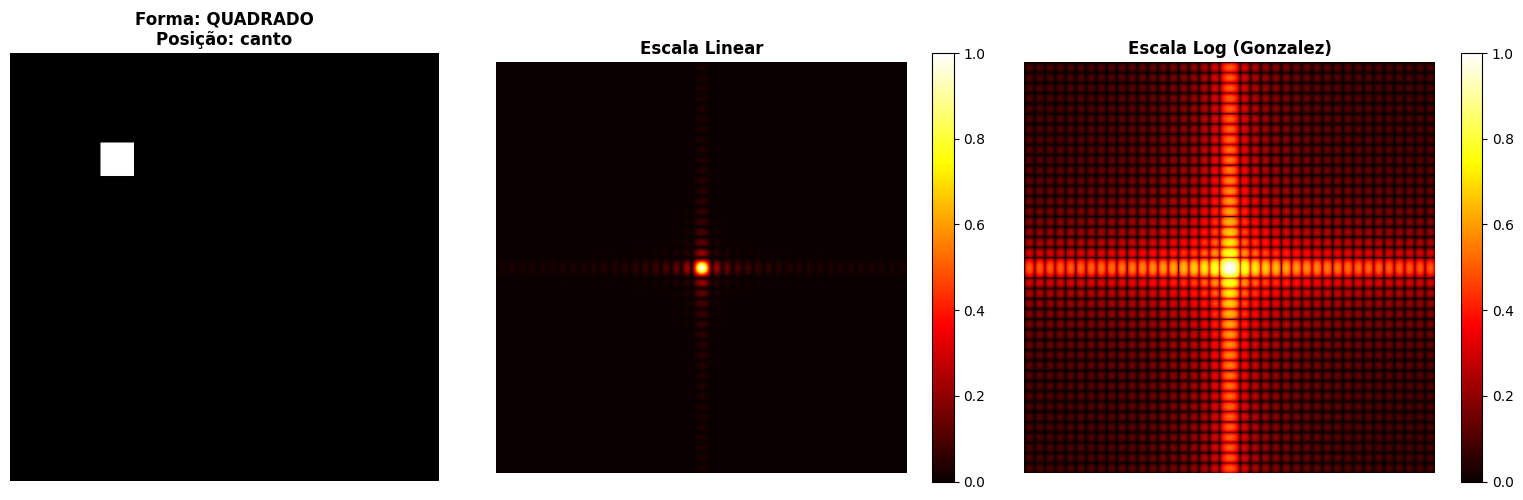


 OBSERVAÇÃO: A magnitude espectral é IDÊNTICA!
   Apenas a FASE muda com a posição (não visualizada aqui).


In [ ]:
# Experimento 3: Efeito da posição (magnitude não muda!)
print("[7] Quadrado no CENTRO")
criar_e_analisar(N=512, forma='quadrado', tamanho=20, posicao='centro')

print("[8] Quadrado no CANTO")
criar_e_analisar(N=512, forma='quadrado', tamanho=20, posicao='canto')

print("\n OBSERVAÇÃO: A magnitude espectral é IDÊNTICA!")
print("   Apenas a FASE muda com a posição (não visualizada aqui).")

## 9. Análise Estatística do Espectro

In [ ]:
def analisar_estatisticas(magnitude, centrado=False):
    """Extrai estatísticas úteis do espectro."""
    if centrado:
        mag = fp.fftshift(magnitude)
    else:
        mag = magnitude

    h, w = mag.shape

    # Calcular regiões
    energia_total = np.sum(mag ** 2)
    energia_centro = np.sum(mag[h//4:3*h//4, w//4:3*w//4] ** 2)
    energia_bordas = energia_total - energia_centro

    pico_idx = np.unravel_index(np.argmax(mag), mag.shape)

    return {
        'energia_total': energia_total,
        'energia_centro': energia_centro,
        'energia_bordas': energia_bordas,
        'percentual_centro': 100 * energia_centro / energia_total,
        'pico_valor': mag[pico_idx],
        'pico_posicao': pico_idx,
        'media': np.mean(mag),
        'mediana': np.median(mag),
        'std': np.std(mag),
    }


stats = analisar_estatisticas(magnitude, centrado=True)

print("\n" + "="*70)
print("ESTATÍSTICAS DO ESPECTRO - Quadrado Centrado")
print("="*70)
for chave, valor in stats.items():
    if isinstance(valor, tuple):
        print(f"{chave:.<30} {valor}")
    elif isinstance(valor, float):
        print(f"{chave:.<30} {valor:.6e}")
    else:
        print(f"{chave:.<30} {valor}")
print("="*70)


ESTATÍSTICAS DO ESPECTRO - Quadrado Centrado
energia_total................. 1677721088.0
energia_centro................ 1651142400.0
energia_bordas................ 26578688.0
percentual_centro............. 98.41577911376953
pico_valor.................... 1600.0
pico_posicao.................. (np.int64(512), np.int64(512))
media......................... 6.173524379730225
mediana....................... 1.0007489919662476
std........................... 39.520721435546875
